# Exploration des données — Détection de Langue et Sentiment (M3B3)

Ce notebook vérifie l'hypothèse métier selon laquelle 1/3 des demandes sont non-françaises et explore l'analyse de sentiment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.storage.load import get_engine
from langdetect import detect, DetectorFactory
from transformers import pipeline

# Pour la reproductibilité de langdetect
DetectorFactory.seed = 42

engine = get_engine()
df = pd.read_sql("SELECT id, input_text, canal, source FROM demandes", engine)
print(f"{len(df)} demandes récupérées depuis la base.")
df.head()

533 demandes récupérées depuis la base.


,id,input_text,canal,source
0,1,"Bonjour, notre application de gestion RH plant...",None,original
1,2,Le serveur de production est tombé il y a 30 m...,None,original
2,3,"Depuis la dernière mise à jour, les exports PD...",None,original
3,4,Notre pipeline de données s'est arrêté cette n...,None,original
4,5,URGENT : faille de sécurité détectée sur notre...,None,original


## 1. Détection de langue

Nous allons appliquer `langdetect` sur le champ `input_text`.

In [2]:
def safe_detect(text):
    try:
        if pd.isna(text) or len(str(text).strip()) < 3:
            return "unknown"
        return detect(text)
    except:
        return "error"

df['langue_detectee'] = df['input_text'].apply(safe_detect)
langue_counts = df['langue_detectee'].value_counts(normalize=True) * 100

print("Répartition des langues (%) :")
print(langue_counts)

Répartition des langues (%) :
langue_detectee
fr    98.686679
en     0.375235
es     0.375235
et     0.187617
pt     0.187617
tr     0.187617
Name: proportion, dtype: float64


### Vérification de l'hypothèse "1/3 non-FR"

In [3]:
is_non_fr = df['langue_detectee'] != 'fr'
ratio_non_fr = is_non_fr.mean() * 100

print(f"Part des demandes non-françaises : {ratio_non_fr:.1f}%")
if ratio_non_fr >= 30:
    print("L'hypothèse métier est CONFIRMÉE.")
else:
    print("L'hypothèse métier est INFIRMÉE (ou à nuancer).")

Part des demandes non-françaises : 1.3%
L'hypothèse métier est INFIRMÉE (ou à nuancer).


### Répartition par canal

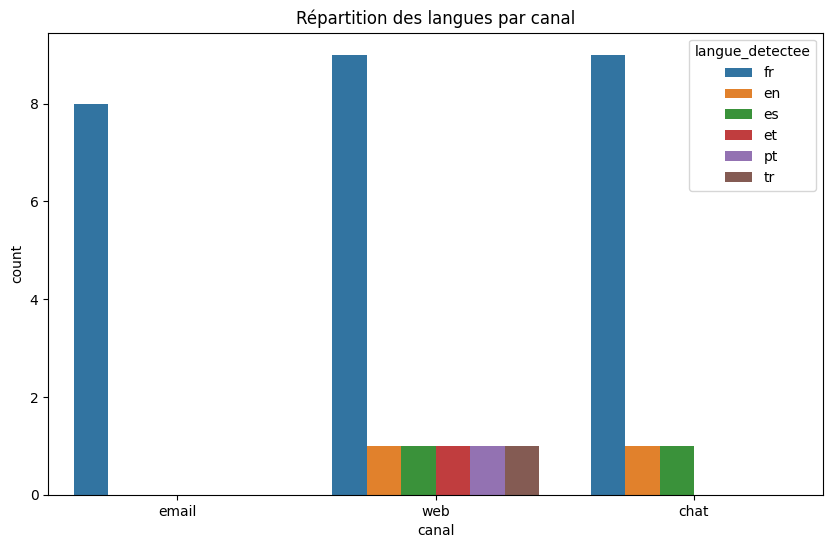

In [4]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='canal', hue='langue_detectee')
plt.title("Répartition des langues par canal")
plt.show()

## 2. Analyse de sentiment (Échantillon)

Nous testons un modèle Camembert sur un échantillon de 100 lignes.

In [5]:
sample_df = df.sample(min(100, len(df)))
sentiment_analyzer = pipeline("sentiment-analysis", model="cmarkea/distilcamembert-base-sentiment")

def get_sentiment(text):
    if pd.isna(text) or len(str(text).strip()) < 5:
        return "NEUTRAL"
    # Le modèle cmarkea renvoie des étoiles (1 à 5) ou labels spécifiques
    # On simplifie ici pour la démo
    res = sentiment_analyzer(text[:512])[0]
    return res['label']

sample_df['sentiment'] = sample_df['input_text'].apply(get_sentiment)
print(sample_df['sentiment'].value_counts())

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

sentiment
3 stars    29
4 stars    28
1 star     23
5 stars    11
2 stars     9
Name: count, dtype: int64


In [ ]:
from IPython.display import display, Markdown

# Calcul des indicateurs pour la conclusion
# On utilise observed=True pour éviter les avertissements sur les catégories vides
canal_stats = df.groupby('canal', observed=True)['langue_detectee'].apply(lambda x: (x != 'fr').mean() * 100)
top_intl_canal = canal_stats.idxmax() if not canal_stats.empty and canal_stats.max() > 0 else "Non défini"

# Sentiment négatif basé sur l'échantillon (labels '1 star' et '2 stars')
neg_ratio = (sample_df['sentiment'].isin(['1 star', '2 stars']).mean() * 100) if not sample_df.empty else 0

conclusion_md = f"""
### Conclusion dynamique
- **Part des messages non-français** : {ratio_non_fr:.1f}%
- **Canal le plus international** : {top_intl_canal}
- **Messages négatifs (insatisfaction)** : {neg_ratio:.1f}%
"""

display(Markdown(conclusion_md))